# Perform a looping with a quadrotor

# Goal of the project

The goal of this project is to control a 2D quadrotor to get it to perform acrobatic moves. The controller will be designed using an SQP solver.

Please submit your code as a runnable Jupyter Notebook.

## 2D quadrotor

The quadrotor is depicted in the following figure
<img src='quadrotor.png' width="300">


The quadrotor model is written as
$$\begin{align} 
\dot{p_x} &= v_x\\
m \dot{v}_x &= - (u_1 + u_2) \sin \theta \\ 
\dot{p_y} &= v_y\\
m \dot{v}_y &= (u_1 + u_2) \cos \theta  - m g\\
\dot{\theta} &= \omega\\
I \dot{\omega} &= r (u_1 - u_2) \end{align}$$
where $p_x$ is the horizontal and $p_y$ the vertical positions of the quadrotor and $\theta$ is its orientation with respect to the horizontal plane. $v_x$ and $v_y$ are the linear velocities and $\omega$ is the angular velocity of the robot. $u_1$ and $u_2$ are the forces produced by the rotors (our control inputs). $m$ is the quadrotor mass, $I$ its moment of inertia (a scalar), $r$ is the distance from the center of the robot frame to the propellers and $g$ is the gravity constant. To denote the entire state, we will write $x = [p_x, v_x, p_y, v_y, \theta, \omega]^T$ - we will also write $u = [u_1, u_2]^T$.

The module ```quadrotor.py``` defines the problem and provides all the useful information about the robot and methods to simulate and animate it as shown below.

You can access the different parameters of the model in the following way:

In [1]:
import quadrotor

print("Mass    =", quadrotor.MASS)
print("Length  =", quadrotor.LENGTH)
print("Inertia =", quadrotor.INERTIA)
print("Dt      =", quadrotor.DT)
print("state size   =", quadrotor.DIM_STATE)
print("control size =", quadrotor.DIM_CONTROL)

Mass    = 0.45
Length  = 0.14
Inertia = 0.09
Dt      = 0.04
state size   = 6
control size = 2




## Part 1 - Setting up the trajectory optimization problem (50 points)
1. Discretize the system dynamics using Euler's method seen in class - write the time discretization step as $\Delta t$ (use symbols not numbers for the mass, etc)
2. We would like the quadrotor to perfom a looping (i.e. a back or front flip). Find and implement a suitable cost function to perform a looping and add constraints to maintain the thrust of each rotor between $0$ and $10$. Solve the problem using your own implementation of a SQP with a long horizon to ensure that you can do a looping.
3. Show plots of all the states and controls of the robot as a function of time. Plot the value of $\alpha$ (during line search) at each iteration of the solver as well as the amount of constraint viol per iteration and the cost per iteration of the solver (also useful to help you debug).
5. Describe your design choices (in a concise manner) in the report.

To visualize the trajectory, use the ```quadrotor.animate_robot``` function and show the animation (show the plots in your report).

### Tips to implement a SQP solver
1. Write down the algorithm (in words not in code), i.e. write all the steps you need to take
2. Write the gradient of the run cost at a given guess $\bar{x} = [{\bar{p}_x}_0, {\bar{v}_x}_0, {\bar{p}_y}_0, {\bar{v}_{y}}_0, \bar{\theta}_0, \bar{\omega}_0, {\bar{u}_1}_0, {\bar{u}_2}_0, \dots, {\bar{p}_x}_N, {\bar{v}_x}_N, {\bar{p}_y}_N, {\bar{v}_{y}}_N, \bar{\theta}_N, \bar{\omega}_N, {\bar{u}_1}_N, {\bar{u}_2}_N,]^T$, i.e. for a given value of these variables and implement a function that computes it
3. Write the Hessian of the run cost at a given guess $\bar{x}$ and implement a function that computes it
4. Assume that the Hessian of the constraints is 0 (i.e. ignore the second order derivatives of the constraints)
5. Write a linear approximation of the constraints at a given guess $\bar{x}$ in a form $G(\bar{x}) \Delta x = g(\bar{x})$ (don't forget the constant terms in g) where $\Delta x$ represents a small variation around $\bar{x}$ and implement a function that computes both $G$ and $g$.
6. Use these functions to setup the inner QP of the SQP (use the library from HW2 to solve the QP).
7. Implement a function that computes the amount of constraint viol for the nonlinear constraints (not the linearized one), i.e. the sum of the absolute values of all the constraints (i.e. assuming constraints of the form $c(x) = 0$ we want to compute $|c(x)|$).
8. Implement a filter linear search to test if a step should be accepted. You will implement the (simplified) filter line search explained below.
9. Terminate the algorithm when you either reached the maximum number of iterations (e.g. 100) or when the KKT optimality conditions are satisfied (within a small margin, e.g. $10^{-4}$).

Once you have a solution, make sure to check that it satisfies the constraints! You can display the robot using the ```animate_robot``` function.

#### (Simple) filter linear search
Once you have a potential step $\textrm{step}_x$, you need to find a step $\alpha$ to update your guess of the solution $x_{guess}$. We will accept a step that either reduces the amount of constraint viol or reduces the cost.

Let's denote $f(x)$ the cost at $x$ and $|c(x)|$ the amount of constraint viol at $x$. Initialize the variable $f_{best} = \infty$ and $c_{best}=\infty$ at the beginning of the SQP. 

Then do the following during the line search.
1. Set $\rho$ to a number between 0 and 1 (e.g. 0.5) and set $\alpha = 1$
2. If $f(x_{guess} + \alpha \textrm{step}_x) < f_{best}$ then set $f_{best} \leftarrow f(x_{guess} + \alpha \textrm{step}_x)$ and accept the step

   Or 

   If $|c(x_{guess} + \alpha \textrm{step}_x)| < c_{best}$ then set $c_{best} \leftarrow |c(x_{guess} + \alpha \textrm{step}_x)|$ and accept the step
3. If the step was not accepted set $\alpha \leftarrow \rho \alpha$ and go back to Step 2.
4. If the step was accepted update the guess $x_{guess} \leftarrow x_{guess} + \alpha \textrm{step}_x$

## Part 2 - Model predictive control (MPC) (50 points)
1. Use the trajectory optimization method from Part I to design a MPC controller and test it using the simulator below (you may need to use a shorter horizon). In particular, verify that it can handle perturbations by calling the ```quadrotor.simulate``` function with ```disturbance = True``` (when setting disturbance to True, the simulator will generate a random perturbation every 1 second). Simulate your controller for 10 seconds, plot the state anc control evolution.
2. Explain your intended design in the report, including the cost function and found control law

The ```quadrotor.simulate``` function takes as an input an initial state, a controller, the number of discrete time steps and a boolean value to indicate the presence of perturbation. The controller has to be a function taking as an input a state and time index and outputting a control vector.

## Bonus (10 points)
Add a state constraint to perform the looping while maintening a positive altitude. Use the origin as an initial state.

In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation
import IPython

def controller(x, t):
    return np.zeros(2)

x_init = np.array([0, 0, 0., 0 ,0, 0])
horizon_length = 100
t, state, u = quadrotor.simulate(x_init, controller, horizon_length, disturbance=True)
quadrotor.animate_robot(state, u)

<source type="video/mp4" src="data:video/mp4;base64,AAAAIGZ0eXBNNFYgAAACAE00ViBpc29taXNvMmF2YzEAAAAIZnJlZQAAMaltZGF0AAACrwYF//+r
3EXpvebZSLeWLNgg2SPu73gyNjQgLSBjb3JlIDE2NCByMzA5NSBiYWVlNDAwIC0gSC4yNjQvTVBF
Ry00IEFWQyBjb2RlYyAtIENvcHlsZWZ0IDIwMDMtMjAyMiAtIGh0dHA6Ly93d3cudmlkZW9sYW4u
b3JnL3gyNjQuaHRtbCAtIG9wdGlvbnM6IGNhYmFjPTEgcmVmPTMgZGVibG9jaz0xOjA6MCBhbmFs
eXNlPTB4MzoweDExMyBtZT1oZXggc3VibWU9NyBwc3k9MSBwc3lfcmQ9MS4wMDowLjAwIG1peGVk
X3JlZj0xIG1lX3JhbmdlPTE2IGNocm9tYV9tZT0xIHRyZWxsaXM9MSA4eDhkY3Q9MSBjcW09MCBk
ZWFkem9uZT0yMSwxMSBmYXN0X3Bza2lwPTEgY2hyb21hX3FwX29mZnNldD0tMiB0aHJlYWRzPTI3
IGxvb2thaGVhZF90aHJlYWRzPTQgc2xpY2VkX3RocmVhZHM9MCBucj0wIGRlY2ltYXRlPTEgaW50
ZXJsYWNlZD0wIGJsdXJheV9jb21wYXQ9MCBjb25zdHJhaW5lZF9pbnRyYT0wIGJmcmFtZXM9MyBi
X3B5cmFtaWQ9MiBiX2FkYXB0PTEgYl9iaWFzPTAgZGlyZWN0PTEgd2VpZ2h0Yj0xIG9wZW5fZ29w
PTAgd2VpZ2h0cD0yIGtleWludD0yNTAga2V5aW50X21pbj0yNSBzY2VuZWN1dD00MCBpbnRyYV9y
ZWZyZXNoPTAgcmNfbG9va2FoZWFkPTQwIHJjPWNyZiBtYnRyZWU9MSBjcmY9MjMuMCBxY29tcD0w
LjYwIHFwbWluPTAgcXBtYXg9NjkgcXBzdGVwPTQgaXBfcmF0aW89MS40MCBhcT0xOjEuMDAAgAAA
ET1liIQAN//+9vD+BTY7mNCXEc3onTMfvxW4ujQ3vc4AAAMAAAMAAAMAADSY0H4zd2rDhiAAAAMA
JgAGCANgAzAEdwBJhifrPwALwRFkBJwPzJUmFGT2qHXo4m6RCitIlhRYet3pioe7PtHMnO4JkntJ
ujXVK9mpvpov1Dq5CrLp26+E/qiy2XJ1DXbFQFIeD6dj4d/Ycg4MlRjSj5F/jO4dneZbKchBkxER
1+dwaLseoQTUOIHe+AjMd/01j3lkHunyumHGATF5QfuGMNEhmAiiUAYOIeHxFiIgg2yx/sREsJlD
kHggnz8ibjDHy6sod15ejTD7nM3nSKn356x7NU+rLjiy+TGV7zlKZBPivMIavE++a9A0lqsJYdgr
ySjKMHT/BXnDAgmDXfO64jpiyGPFAqtkFWJ5TEQleZ1J5ApIiAbrmpifDenz7+L/Amzw77yl2Tw8
dV/vzdYNgHyNMQMYbCtp3Te5K1aVTFFV6sDhAOBm+U1wqSLvWAJb5Z17JHtr26nfayIkr84mLavN
uYtEd070a0a9ZsTjkRA15H+YtuFUCQvHDIWte6k4UzfB4Yq1VXewvcePau7Rj9tHaZL1WJ7N/1Z9
0FlymQ8bG0uvPqkmhksanP5XoUMxyuop4wtHxWyQ0pIDVe6n4Pcoo/9RyuTt19uWVECJXQ5P1Hx7
VV5QkudKISdWqDkh+ASDXfCQtNT2BXDqBcJctYky35tVgovwxSWB9HCZVH5N37v/voXSu8KEpezs
oE9qt1TswCfHduuEi3fqkotD8eFmv/l+ScnPy60UANVTK/HDzZWI8x+5xekmij7yT4ZzPx+mM4Bi
WhufWWO5sMYfOyIS/jQF9gCxCCBlTF+Ll7iYRrc5ePlMRdy7xttblO/VcOplWfZ8JQMSsAUlD3YB
/qYqaOgIzP4erjoJ3m6AFmklSccMmtC0Lz3KmzNhftyABNqitSgygaBGGDhZY2NnP2n6AoxeDymi
cFsx5q3xKqjR5yV6AW6qn55mnNuagTbBCVIi6ilTVCpaRXGEyUZlIdLNtb6IdpWgLyzcE+P/Ln9+
pgtfMGenP64mVznurjL2XaWI3DDyq/j3rE9lZWH4X/6QhM/9VtmKTD2lD94xSjdU6fqIQ2A8cJcM
RkuAz46JiJvBAluFpxkTGBBaOKe/hQFJw9yrkHr8wriqU0h9k8YL0OMV2Z2C6Np98rEgko84zI5l
VraFki8TtmgCzbEX8hvLRjas69gk0h8bOqb2+N5VnEq+hzyLZb50IOi2/T09Ov1L1p6kqXU55C5i
/++EhgoBvipBP6AXmv+URURZtpxZKswbwDJvFoeY7fxMAehvIwfCWzsMSLXVMZYdMUU58+NIQvEF
YyRQULyi9LF1URfJaD/ZGAAAAwAABItkYHBEhuEAAHtyWTpSFAAEJ4YhNbDZ+5WUyI0DWql1EM2J
ULI+zE/MpWi2aTheyw0aYP70ibuWiEfV+iuNmMvpCKRcJ4zFWHEtGkPo2WpfPfb9FYopSOMUOfUm
ePX4JdHEUWTF+0MbrZvi0UHONrFeuAxuOhUPgoxNMrNrG9Zq+tkWfYzYmJW0UsDNDG5F6VWQ31dO
5pDAOUDqALHsFEXSBfolUhDQyVadtUJWMiYYJYlprKOzzta0zXYm8H2R/vmyhhG3rlYxusNVZJFg
DrLk1NoKn7ebX9WsVu6HFHXprNN+DoJYac1KN9D5zd+BXDINIKWzJkUqSL4ut3oAzmaZazgY+ha/
Esg3hC+b06vNQgI+m8V9IoQfuAa0bOnN17qumoba9GGb2WgFrB8jD6/yCwADK2YjMGFemq/IUnM5
POpF4GqmfUksYl3I9TP+lPfm48H1dNBfmK6ycMIF27wAXaVkA9dJ3S8GiPoH/Qt1OEfsYPOe8AFA
8Loo3KemBdcngJYxlOFhypAAAAMAAKFTRwx/+6PubHCqOAB0eKyCo5ro/oiG/+Y2FGICCnlsjADc
RruQaHdTTH9S/54YEWIiRXC5n55ePR/JerRnTVKhPh9VDjWLqruO84748BmhNnJ0bHG/FgMwWLC4
/S08Vlc19Blt092AWIiikdA9j29/0QzmG/MrTqiamXA2OF0R/VheX941FdCDzte+KjsbReCgIftd
VYdB/8grwG8hyvbGgP6Rdpg6IUzDNy2RalPB+WvqU2ySTQ/dVvqMqRxjQs9/eU9hGaIodqk8s5yX
rV+v1H97XdrecB9S5iXM5S+XuPq8cZbOUqD/v/nUeTrBh9dGAqk3dAWT9NR+z8LXKAq6qjhUaIbW
YBPG99HF9P/snemF3lqW47D972widvmx6ookLR/A1Vij8c89a+2yzV/qKf1JbJXUZrD1Iibxzsly
TV/98cRNpzHgA6+wkqQrS4iWIkckm6Yvwf2uZ8EoH1eS2+lW0RnT+5n0S8YyvhcQlEwQVDDHs36z
6GUPkEE7lRwmIzkalMzcq0dWVzZ1QoKDblFnfguar6vVXUCucH4gwK/pPYH127TW6TvmyiIJ7wgi
07qWs2geM0gN39ELjnLzwFbA5b0wtqTRSQuNorWGPEwev4j+49jK6AgaanwPQmuEV+JY2Dlbbcz+
Li70jmyuoi1oqeGLZBmTnyytlGEK2ahVozIvfzbtLhjCsy072+5i6BtSxdezuVjKuITyHZqEm+er
ehQr7ROAPMVP7nW1oIK7m+9GbLj2JfjaY0p+pJMBxP/7vIhAzPnsaGgUsp9qbBPyMOA1+UkkrjL8
j9CCkk2gDnWrpowPZYW4zP7EpCmUalkDi6aiIpvObnJsxU36reAlp/iyymx2XmmzI/EYAl2vrG/O
9hAhbvN/akEEWPbwXgCdq8/9ijgJTLhCYQ1C5+VsReqsj/qI5STZlSeBwGOWs1kQAH3PrBv4lpSZ
g68i7AjD4Iqj2mKo1EAVS

1st Guess: Cost=197574.7862, viol=0.0000
Iter 01: Cost =4953.9750, Viol =36.6987, Step =66.8794, Alpha =1.0000
Iter 02: Cost =1455.7443, Viol =11.4056, Step =53.8384, Alpha =1.0000
Iter 03: Cost =1151.7271, Viol =1.0366, Step =19.4232, Alpha =1.0000
Iter 04: Cost =1044.8500, Viol =1.0079, Step =11.2259, Alpha =1.0000
Iter 05: Cost =991.2562, Viol =0.3198, Step =8.3071, Alpha =1.0000
Iter 06: Cost =962.7550, Viol =0.1903, Step =6.4591, Alpha =1.0000
Iter 07: Cost =948.2465, Viol =0.1061, Step =4.5453, Alpha =1.0000
Iter 08: Cost =939.2632, Viol =0.0612, Step =3.4201, Alpha =1.0000
Iter 09: Cost =934.6868, Viol =0.0287, Step =2.5614, Alpha =1.0000
Iter 10: Cost =932.3452, Viol =0.0165, Step =1.8399, Alpha =1.0000
Iter 11: Cost =930.8535, Viol =0.0129, Step =1.5044, Alpha =1.0000
Iter 12: Cost =929.6685, Viol =0.0132, Step =1.5482, Alpha =1.0000
Iter 13: Cost =928.4736, Viol =0.0115, Step =1.4805, Alpha =1.0000
Iter 14: Cost =927.5511, Viol =0.0078, Step =1.3638, Alpha =1.0000
Iter 15: Co

Your browser does not support the video tag.

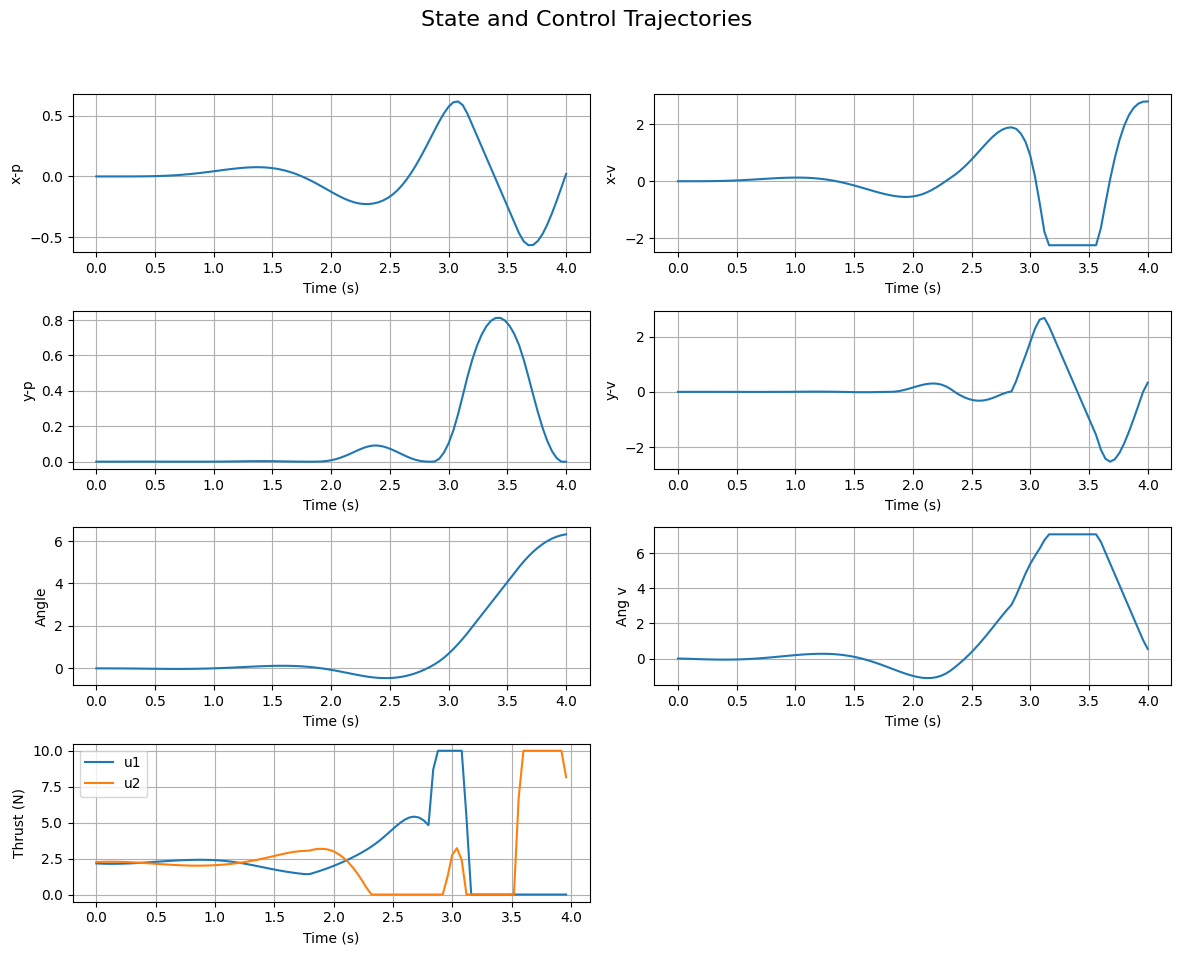

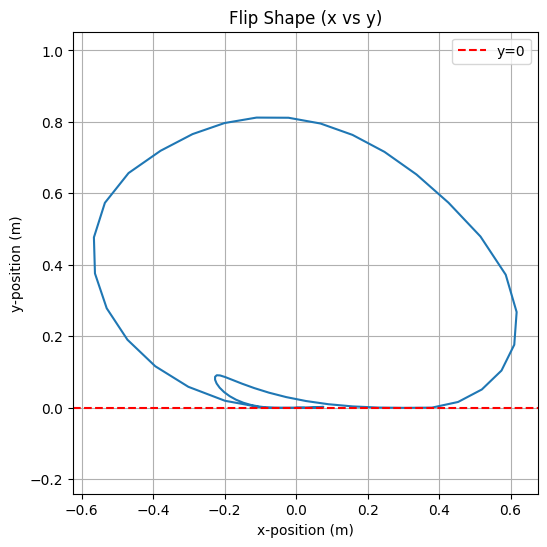

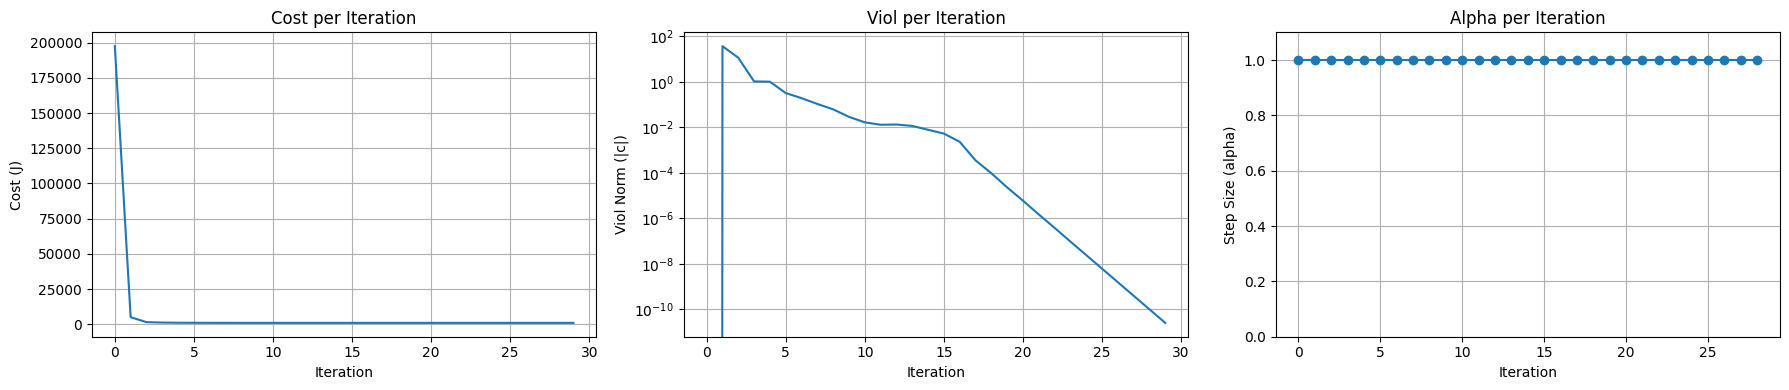

In [3]:
## write down your code here
import numpy as np
import quadrotor
from quadrotor import next_state
from qpsolvers import solve_qp
import matplotlib.pyplot as plt

def get_cost_matrix_G(Q,R,Qf):
    G = np.zeros((nvars, nvars))
    for i in range(N):
        # state cost (x_n)
        idx_x = i * (xdim + udim)
        G[idx_x:(idx_x + xdim), idx_x:(idx_x + xdim)] = Q
        
        # control cost (u_n)
        idx_u = idx_x + xdim
        G[idx_u:(idx_u + udim), idx_u:(idx_u + udim)] = R
    idx_xN = (N)*(xdim + udim)
    G[idx_xN:(idx_xN + xdim), idx_xN:(idx_xN + xdim)] = Qf
    return G

def calc_cost_grad(Z_guess,Q,R,Qf,x_target):
    g = np.zeros(nvars)
    x = np.zeros((xdim,N + 1))
    u = np.zeros((udim,N))
    for n in range(N):
        idx_x = (n)*(xdim + udim)
        x[:,n] = Z_guess[idx_x:(idx_x + xdim)]
        u[:,n] = Z_guess[(idx_x + xdim):(idx_x+xdim+udim)] 
    x[:, N] = Z_guess[N*(xdim+udim):N*(xdim+udim)+xdim]
    for n in range(N):
        idx_x = n*(xdim+udim) 
        idx_u = idx_x + xdim      
        g[idx_x:(idx_x+xdim)] = Q @ x[:,n]
        g[idx_u:(idx_u+udim)] = R @ u[:,n]
    g[N*(xdim+udim):N*(xdim+udim) + xdim] = Qf @ (x[:,N] - x_target) 
    return g

def calc_A(x_n, u_n):
    px = x_n[0]
    vx = x_n[1]
    py = x_n[2]
    vy = x_n[3]
    theta = x_n[4]
    w = x_n[5]
    u1 = u_n[0]
    u2 = u_n[1]
    grad_dx = np.zeros((xdim, xdim))
    
    grad_dx[0,1] = 1.0 
    grad_dx[1,4] = -(u1 + u2)*(np.cos(theta))/quadrotor.MASS 
    grad_dx[2,3] = 1.0 
    grad_dx[3,4] = -(u1 + u2)*(np.sin(theta))/quadrotor.MASS 
    grad_dx[4,5] = 1.0 
    grad_dx[5,:]  = [0,0,0,0,0,0]
    A_n = np.eye(xdim) + (quadrotor.DT)*(grad_dx) 
    return A_n
    
def calc_B(x_n, u_n):
    px = x_n[0]
    vx = x_n[1]
    py = x_n[2]
    vy = x_n[3]
    theta = x_n[4]
    w = x_n[5]
    u1 = u_n[0]
    u2 = u_n[1]
    grad_du = np.zeros((xdim, udim))
    
    grad_du[0,:] = [0,0]
    grad_du[1,0] = -(np.sin(theta))/quadrotor.MASS
    grad_du[1,1] = -(np.sin(theta))/quadrotor.MASS
    grad_du[2,:] = [0,0]
    grad_du[3,0] = np.cos(theta)/quadrotor.MASS
    grad_du[3,1] = np.cos(theta)/quadrotor.MASS
    grad_du[4,:] = [0,0]
    grad_du[5,0] = quadrotor.LENGTH/quadrotor.INERTIA
    grad_du[5,1] = -(quadrotor.LENGTH)/quadrotor.INERTIA
    B_n = quadrotor.DT * grad_du 
    return B_n

def build_M_and_p(Z_guess,x_init):
    n_constr = (N + 1)*(xdim)
    M = np.zeros((n_constr,nvars))
    p = np.zeros(n_constr)
    x = np.zeros((xdim,N + 1))
    u = np.zeros((udim,N))
    
    idx_xN = (N)*(xdim + udim) 
    for n in range(N):
        idx_x = (n)*(xdim + udim)
        idx_u = idx_x + xdim
        x[:,n] = Z_guess[idx_x:(idx_x + xdim)]
        u[:,n] = Z_guess[idx_u:(idx_u + udim)]
    x[:,N] = Z_guess[idx_xN:(idx_xN + xdim)]
    M[0:xdim,0:xdim] = np.eye(xdim)
    p[0:xdim] = x_init.flatten()
    
    for n in range(N):
        x_n = x[:,n]
        u_n = u[:,n]
        x_n_p1 = x[:,n+1]
        x_np1_pred = next_state(x_n,u_n)
        A_n = calc_A(x_n,u_n)
        B_n = calc_B(x_n,u_n)
        
        row_idx_start = (n+1)*(xdim)
        row_idx_end   = (n+2)*(xdim)
        col_idx_xn   = (n)*(xdim + udim)
        col_idx_un   = col_idx_xn + xdim
        col_idx_xn_1 = (n + 1)*(xdim + udim)

        M[row_idx_start:row_idx_end,col_idx_xn:col_idx_un]       = A_n
        M[row_idx_start:row_idx_end, col_idx_un:(col_idx_un+udim)]   = B_n
        M[row_idx_start:row_idx_end,col_idx_xn_1:(col_idx_xn_1+xdim)] = -(np.eye(xdim))
        
        p[row_idx_start:row_idx_end] = x_n_p1 - x_np1_pred 
    return M, p

def init_Guess(x_init):
    Z_guess = np.zeros(nvars)
    x_guess = np.zeros((xdim, N + 1))
    u_guess = np.zeros((udim, N))
    x_guess[:,0] = x_init
    
    # First Control Guess
    u_hover = np.array([(quadrotor.MASS)*(quadrotor.GRAVITY_CONSTANT)/2.0, (quadrotor.MASS)*(quadrotor.GRAVITY_CONSTANT)/2.0])
    for n in range(N):
        u_guess[:, n] = u_hover
        x_guess[:, n+1] = next_state(x_guess[:, n], u_guess[:, n])   
    # Pack into Z_guess
    for n in range(N):
        idx_x = (n)*(xdim + udim)
        idx_u = idx_x + xdim
        Z_guess[idx_x:(idx_x + xdim)] = x_guess[:, n]
        Z_guess[idx_u:(idx_u + udim)] = u_guess[:, n]
    idx_xN = N*(xdim + udim)
    Z_guess[idx_xN:(idx_xN + xdim)] = x_guess[:, N]
    return Z_guess

def NLCostViol(Z,Q,R,Qf,x_target,x_init):
    x = np.zeros((xdim,N + 1))
    u = np.zeros((udim,N))
    for n in range(N):
        idx_x = n*(xdim + udim)
        x[:,n] = Z[idx_x:(idx_x + xdim)]
        u[:,n] = Z[(idx_x + xdim):(idx_x + xdim + udim)]
    idx_xN = N*(xdim + udim)
    x[:, N] = Z[idx_xN:(idx_xN + xdim)]

    cost = 0.0
    for n in range(N):
        cost += 0.5*(x[:,n].T @ Q @ x[:,n] + u[:,n].T @ R @ u[:,n])
    cost += (0.5)*(x[:,N]-x_target).T @ Qf @ (x[:,N]-x_target)
    viol = 0.0
    viol += np.sum(np.abs(x[:,0] - x_init))
    for n in range(N):
        x_np1_pred = next_state(x[:,n], u[:, n])
        viol += np.sum(np.abs(x_np1_pred - x[:, n+1]))
    for n in range(N):
        viol += np.sum(np.maximum(0,u[:,n] - u_max))
        viol += np.sum(np.maximum(0,u_min - u[:,n]))
    epsilon = 1e-4
    for n in range(N + 1):
        viol += np.sum(np.maximum(0, -x[2, n] - epsilon))
    return cost, viol

def line_search(Z_k, dZ, cost_k, viol_k):
    global f_best, c_best
    alpha = 1.0
    rho = 0.5
    for i in range(100):
        Z_new = Z_k + (alpha)*(dZ)
        cost_new, viol_new = NLCostViol(Z_new,Q_run,R_run,Qf,x_target,x_init)
        if (cost_new<f_best)or(viol_new<c_best):
            if cost_new < f_best:
                f_best = cost_new
            if viol_new < c_best:
                c_best = viol_new
            return alpha,cost_new,viol_new
        alpha = alpha*rho
    return 0.0, cost_k, viol_k

def extract_Sol(Z):
    x_sol = np.zeros((xdim,N + 1))
    u_sol = np.zeros((udim,N))
    for i in range(N):
        idx_x = i*(xdim+udim)
        x_sol[:,i] = Z[idx_x:(idx_x+xdim)]
        u_sol[:,i] = Z[(idx_x+xdim):(idx_x+xdim+udim)]
    x_sol[:,N] = Z[N*(xdim+udim):N*(xdim+udim)+xdim]
    return x_sol, u_sol
#-----------------------------------------
xdim = quadrotor.DIM_STATE 
udim = quadrotor.DIM_CONTROL 
x_init = np.zeros(xdim) 
x_target = np.array([0,0,0,0,2*np.pi,0]) 
N = 100 
nvars = (N*udim) + ((N+1)*xdim)
u_max = np.array([10.0,10.0])
u_min = np.array([0.0,0.0]) 
Q_run = np.diag([20.0,0.1,70.0,0.1,0,0.1])
Qf = np.diag([1000,10,1000,10,10000,100])
R_run = np.eye(udim)*0.375
f_best = float('inf')
c_best = float('inf')

max_iter = 100
convg_tol = 1e-4
G = get_cost_matrix_G(Q_run,R_run,Qf)
n_ineq_ctrl = 4*N     
n_ineq_state = N + 1     
n_ineq = n_ineq_ctrl + n_ineq_state

H = np.zeros((n_ineq, nvars)) 
Z_guess = init_Guess(x_init)
cost_k, viol_k = NLCostViol(Z_guess,Q_run,R_run, Qf, x_target, x_init)

if cost_k < f_best: 
    f_best = cost_k
if viol_k < c_best: 
    c_best = viol_k
    
print(f"1st Guess: Cost={cost_k:.4f}, viol={viol_k:.4f}")

costs_per_iter = [cost_k]
viols_per_iter = [viol_k]
alphas_per_iter = []

# SQP
for k in range(max_iter):
    g = calc_cost_grad(Z_guess,Q_run,R_run,Qf,x_target)
    M, p = build_M_and_p(Z_guess,x_init)
    
    x_guess, u_guess = extract_Sol(Z_guess)
    h = np.zeros(n_ineq)
    row_idx = 0
    for n in range(N):
        idx_u1 = n*(xdim + udim) + xdim
        idx_u2 = idx_u1 + 1
        H[row_idx,idx_u1] = 1.0  
        H[row_idx + 1,idx_u2] = 1.0  
        H[row_idx + 2,idx_u1] = -1.0 
        H[row_idx + 3,idx_u2] = -1.0
        row_idx += 4
    row_idx = 0
    for n in range(N):
        h[row_idx]     = u_max[0] - u_guess[0,n] 
        h[row_idx + 1] = u_max[1] - u_guess[1,n] 
        h[row_idx + 2] = u_guess[0, n] - u_min[0] 
        h[row_idx + 3] = u_guess[1, n] - u_min[1] 
        row_idx += 4
    epsilon = 1e-4
    for n in range(N + 1):
        idx_xn_2 = n * (xdim + udim) + 2 
        H[row_idx, idx_xn_2] = -1.0      
        h[row_idx] = x_guess[2, n] + epsilon 
        row_idx += 1
    dZ = solve_qp(G,g.flatten(),H,h,M,p,solver='cvxopt')
        
    alpha, cost_k, viol_k = line_search(Z_guess,dZ,cost_k,viol_k)
    alphas_per_iter.append(alpha)
    costs_per_iter.append(cost_k)
    viols_per_iter.append(viol_k)
    
    if alpha == 0.0:
        break 
    Z_guess = Z_guess + (alpha)*(dZ)
    step = np.linalg.norm(alpha * dZ)
    print(f"Iter {k+1:02d}: Cost ={cost_k:.4f}, Viol ={viol_k:.4f}, Step ={step:.4f}, Alpha ={alpha:.4f}")
    
    if step < convg_tol and viol_k < (convg_tol*(N + 1)):
        print("\nConverged")
        break

x_sol, u_sol = extract_Sol(Z_guess)
x_ref_full = x_sol      # from Part 1
u_ref_full = u_sol
print("Final Cost:", cost_k)
print("Final Viol:", viol_k)
quadrotor.animate_robot(x_sol,u_sol)
time_states = np.arange(N+1)*quadrotor.DT
time_controls = np.arange(N)*quadrotor.DT

# State and Control Plots
plt.figure(figsize=(12,10))
plt.suptitle("State and Control Trajectories", fontsize=16)
state_labels = ['x-p','x-v','y-p','y-v','Angle','Ang v']
for i in range(6):
    plt.subplot(4,2, i+1)
    plt.plot(time_states, x_sol[i, :])  
    plt.ylabel(state_labels[i])
    plt.xlabel('Time (s)')
    plt.grid(True)
plt.subplot(4, 2, 7)
plt.plot(time_controls, u_sol[0,:], label='u1')
plt.plot(time_controls, u_sol[1,:], label='u2')
plt.ylabel('Thrust (N)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(x_sol[0, :], x_sol[2, :])
plt.title('Flip Shape (x vs y)')
plt.xlabel('x-position (m)')
plt.ylabel('y-position (m)')
plt.axhline(0, color='r', linestyle='--', label='y=0')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
plt.plot(costs_per_iter)
plt.title('Cost per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(viols_per_iter)
plt.title('Viol per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Viol Norm (|c|)')
plt.yscale('log') 
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(alphas_per_iter, 'o-')
plt.title('Alpha per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Step Size (alpha)')
plt.ylim(0, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

[NMPC] t=0, u_first=[2.166, 2.251], angle=-0.000, ang_vel=0.000, cost=1.488e-05, viol=1.632e-15
[NMPC] t=1, u_first=[1.276, 0.000], angle=-0.000, ang_vel=-0.755, cost=5.350e+02, viol=2.204e-07
[NMPC] t=2, u_first=[2.105, 0.000], angle=-0.030, ang_vel=-0.676, cost=4.542e+02, viol=5.777e-08
[NMPC] t=3, u_first=[2.155, 0.000], angle=-0.057, ang_vel=-0.545, cost=3.946e+02, viol=5.904e-08
[NMPC] t=4, u_first=[2.189, 0.000], angle=-0.079, ang_vel=-0.411, cost=3.549e+02, viol=3.720e-08
[NMPC] t=5, u_first=[2.604, 0.571], angle=-0.096, ang_vel=-0.275, cost=3.295e+02, viol=4.023e-10
[NMPC] t=6, u_first=[2.988, 2.501], angle=-0.106, ang_vel=-0.148, cost=3.123e+02, viol=1.237e-10
[NMPC] t=7, u_first=[2.592, 2.167], angle=-0.112, ang_vel=-0.118, cost=2.988e+02, viol=4.805e-11
[NMPC] t=8, u_first=[2.532, 2.144], angle=-0.117, ang_vel=-0.092, cost=2.871e+02, viol=1.821e-11
[NMPC] t=9, u_first=[2.492, 2.128], angle=-0.121, ang_vel=-0.067, cost=2.765e+02, viol=6.927e-12
[NMPC] t=10, u_first=[2.463, 2.

Your browser does not support the video tag.

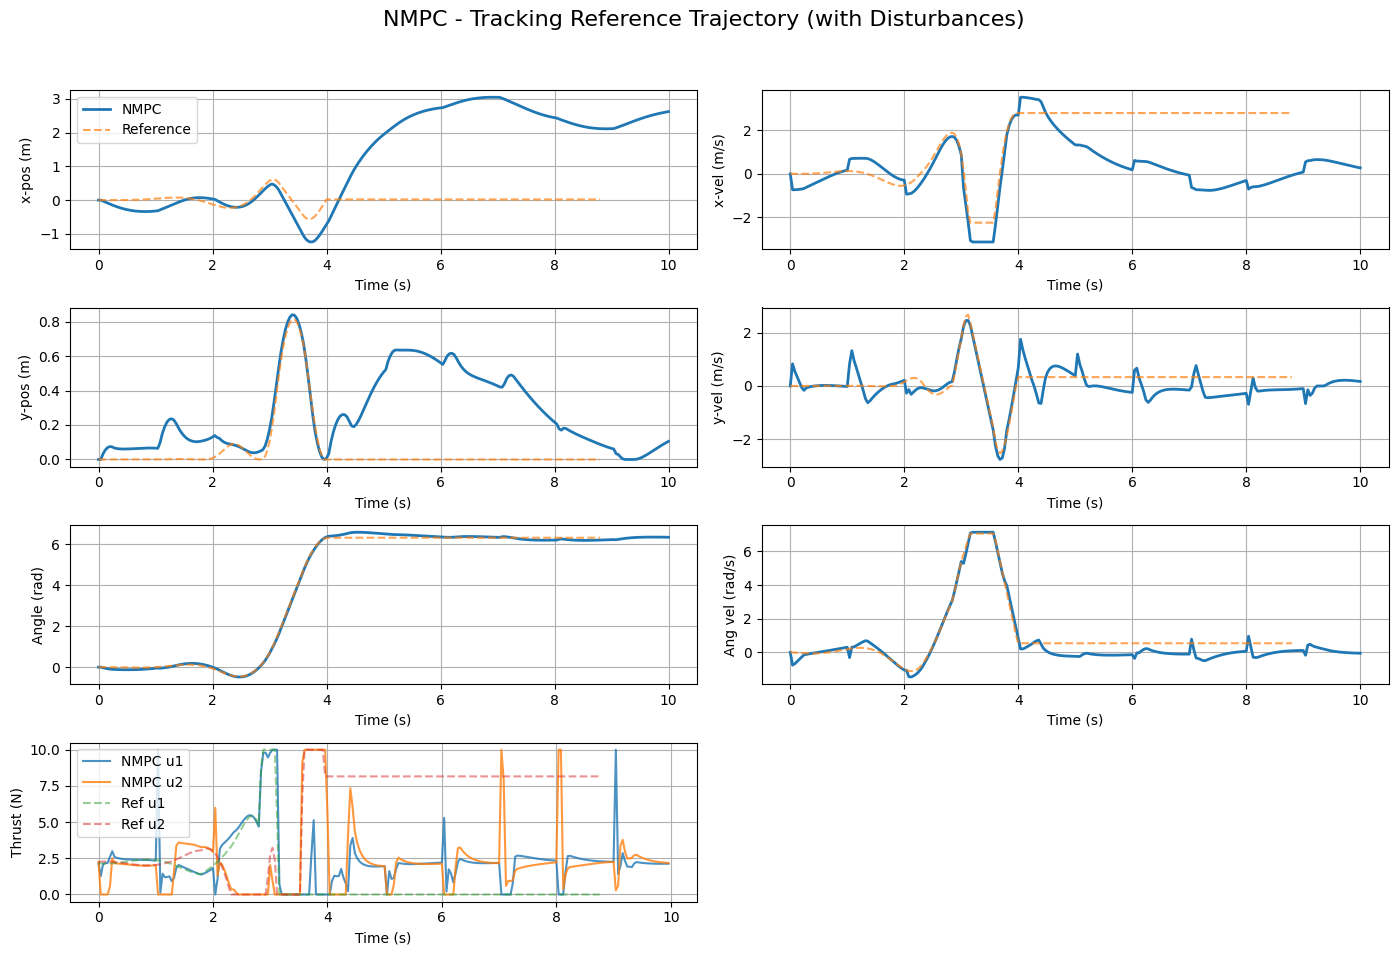

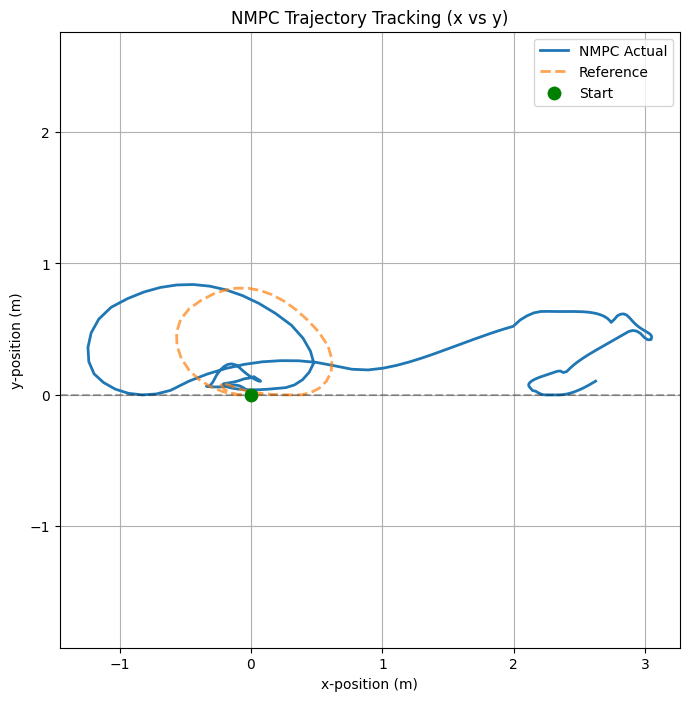

In [5]:
import numpy as np
import quadrotor
from quadrotor import next_state
from qpsolvers import solve_qp
from scipy.linalg import solve_discrete_are
import matplotlib.pyplot as plt
import time


N_mpc = 30                     # horizon length requested
R_stage = 0.01 * np.eye(quadrotor.DIM_CONTROL)
sqp_iters_per_step = 5         # SQP iters per MPC step (RTI-style)
eps_reg = 1e-8                 # Hessian regularization for QP
line_search_max = 6
alpha_rho = 0.5


xdim = quadrotor.DIM_STATE
udim = quadrotor.DIM_CONTROL
u_eq = np.array([quadrotor.MASS * quadrotor.GRAVITY_CONSTANT / 2.0,
                 quadrotor.MASS * quadrotor.GRAVITY_CONSTANT / 2.0])
u_min = np.array([0.0, 0.0])
u_max = np.array([10.0, 10.0])


def pack_from_traj(x_traj, u_traj, Nloc):
    nvars = (Nloc * udim) + ((Nloc + 1) * xdim)
    Z = np.zeros(nvars)
    for n in range(Nloc):
        idx_x = n * (xdim + udim)
        idx_u = idx_x + xdim
        Z[idx_x: idx_x + xdim] = x_traj[:, n]
        Z[idx_u: idx_u + udim] = u_traj[:, n]
    idx_xN = Nloc * (xdim + udim)
    Z[idx_xN: idx_xN + xdim] = x_traj[:, Nloc]
    return Z

def unpack_Z(Z, Nloc):
    expected_len = (Nloc * udim) + ((Nloc + 1) * xdim)
    if Z.size != expected_len:
        raise ValueError(f"unpack_Z: Z has size {Z.size} but expected {expected_len} for Nloc={Nloc}")
    x = np.zeros((xdim, Nloc + 1))
    u = np.zeros((udim, Nloc))
    for n in range(Nloc):
        idx_x = n * (xdim + udim)
        x[:, n] = Z[idx_x: idx_x + xdim]
        u[:, n] = Z[idx_x + xdim: idx_x + xdim + udim]
    idx_xN = Nloc * (xdim + udim)
    x[:, Nloc] = Z[idx_xN: idx_xN + xdim]
    return x, u

if 'x_sol' in globals() and 'u_sol' in globals():
    x_ref_full = x_sol.copy()
    u_ref_full = u_sol.copy()
elif 'x_ref_full' in globals() and 'u_ref_full' in globals():
    x_ref_full = x_ref_full.copy()
    u_ref_full = u_ref_full.copy()


pad_multiplier = 4
pad_len = int(pad_multiplier * N_mpc)
x_ref_padded = np.hstack([x_ref_full, np.tile(x_ref_full[:, -1].reshape(-1, 1), (1, pad_len))])
if u_ref_full.shape[1] > 0:
    u_ref_padded = np.hstack([u_ref_full, np.tile(u_ref_full[:, -1].reshape(-1, 1), (1, pad_len))])
else:
    u_ref_padded = np.tile(u_eq.reshape(-1, 1), (1, pad_len))

def get_ref_state(idx_global):
    idx = int(idx_global)
    idx = min(idx, x_ref_padded.shape[1] - 1)
    return x_ref_padded[:, idx]

def get_ref_control(idx_global):
    idx = int(idx_global)
    idx = min(idx, u_ref_padded.shape[1] - 1)
    return u_ref_padded[:, idx]


A_hover = calc_A(np.zeros(xdim), u_eq)
B_hover = calc_B(np.zeros(xdim), u_eq)
R_stage_mat = R_stage if isinstance(R_stage, np.ndarray) else np.eye(udim) * float(R_stage)
P_terminal = solve_discrete_are(A_hover, B_hover,
                                np.diag([200.0, 5.0, 200.0, 5.0, 1000.0, 50.0]),
                                R_stage_mat)
K_lqr = np.linalg.inv(R_stage_mat + B_hover.T @ P_terminal @ B_hover) @ (B_hover.T @ P_terminal @ A_hover)

def lqr_fallback_u(x):
    dx = x - np.zeros(xdim)
    du = -K_lqr @ dx
    ucmd = u_eq + du
    return np.clip(ucmd, u_min, u_max)

# ------------------ Warm-start persistence & helpers ------------------
try:
    prev_Zwarm
except NameError:
    prev_Zwarm = None

def shift_prev_Zwarm(prev_Zwarm_in):
    if prev_Zwarm_in is None:
        return None
    shift = xdim + udim
    if prev_Zwarm_in.size != (N_mpc * udim + (N_mpc + 1) * xdim):
        # If stored warm isn't same size, discard it
        return None
    Znew = np.zeros_like(prev_Zwarm_in)
    if prev_Zwarm_in.size > shift:
        Znew[:-shift] = prev_Zwarm_in[shift:]
        Znew[-shift:] = prev_Zwarm_in[-shift:]
    else:
        Znew[:] = prev_Zwarm_in.copy()
    return Znew

def warm_start_from_ref(idx_global):
    x_w = np.zeros((xdim, N_mpc + 1))
    u_w = np.zeros((udim, N_mpc))
    for k in range(N_mpc + 1):
        x_w[:, k] = get_ref_state(idx_global + k)
    for k in range(N_mpc):
        u_w[:, k] = get_ref_control(idx_global + k)
    u_w = np.clip(u_w, u_min.reshape(-1, 1), u_max.reshape(-1, 1))
    return pack_from_traj(x_w, u_w, N_mpc)

def track_cost_and_viol(Z, idx_global, Q_stage_local, R_stage_local, Qf_local):
    x, u = unpack_Z(Z, N_mpc)
    cost = 0.0
    viol = 0.0
    for k in range(N_mpc):
        x_ref_k = get_ref_state(idx_global + k)
        u_ref_k = get_ref_control(idx_global + k)
        dx = x[:, k] - x_ref_k
        du = u[:, k] - u_ref_k
        cost += 0.5 * (dx.T @ Q_stage_local @ dx + du.T @ R_stage_local @ du)
        x_np1_pred = next_state(x[:, k], u[:, k])
        viol += np.sum(np.abs(x_np1_pred - x[:, k + 1]))
        # broadcasting-safe control bounds violation
        viol += np.sum(np.maximum(0.0, u[:, k] - u_max.reshape(-1, 1)))
        viol += np.sum(np.maximum(0.0, u_min.reshape(-1, 1) - u[:, k]))
    xN_ref = get_ref_state(idx_global + N_mpc)
    dxN = x[:, N_mpc] - xN_ref
    cost += 0.5 * (dxN.T @ Qf_local @ dxN)
    eps = 1e-6
    viol += np.sum(np.maximum(0.0, -x[2, :] - eps))
    return cost, float(viol)

def build_local_G(Q_stage_local, R_stage_local, Qf_local):
    nvars_local = (N_mpc * udim) + ((N_mpc + 1) * xdim)
    G = np.zeros((nvars_local, nvars_local))
    for i in range(N_mpc):
        idx_x = i * (xdim + udim)
        idx_u = idx_x + xdim
        G[idx_x:idx_x + xdim, idx_x:idx_x + xdim] = Q_stage_local
        G[idx_u:idx_u + udim, idx_u:idx_u + udim] = R_stage_local
    idx_xN = N_mpc * (xdim + udim)
    G[idx_xN:idx_xN + xdim, idx_xN:idx_xN + xdim] = Qf_local
    return G

def build_local_M_p(Z_guess):
    n_constr = (N_mpc + 1) * xdim
    M = np.zeros((n_constr, Z_guess.size))
    p = np.zeros(n_constr)
    xg, ug = unpack_Z(Z_guess, N_mpc)
    M[0:xdim, 0:xdim] = np.eye(xdim)
    for n in range(N_mpc):
        x_n = xg[:, n].copy()
        u_n = ug[:, n].copy()
        x_np1 = xg[:, n + 1].copy()
        x_np1_pred = next_state(x_n, u_n)
        A_n = calc_A(x_n, u_n)
        B_n = calc_B(x_n, u_n)
        row_start = (n + 1) * xdim
        row_end = (n + 2) * xdim
        col_xn = n * (xdim + udim)
        col_un = col_xn + xdim
        col_xn1 = (n + 1) * (xdim + udim)
        M[row_start:row_end, col_xn:col_xn + xdim] = A_n
        M[row_start:row_end, col_un:col_un + udim] = B_n
        M[row_start:row_end, col_xn1:col_xn1 + xdim] = -np.eye(xdim)
        p[row_start:row_end] = x_np1 - x_np1_pred
    return M, p

def build_local_H_h(Z_guess):
    n_ineq = 4 * N_mpc + (N_mpc + 1)
    H = np.zeros((n_ineq, Z_guess.size))
    h = np.zeros(n_ineq)
    xg, ug = unpack_Z(Z_guess, N_mpc)
    row = 0
    for n in range(N_mpc):
        idx_u1 = n * (xdim + udim) + xdim
        idx_u2 = idx_u1 + 1
        H[row, idx_u1] = 1.0
        H[row + 1, idx_u2] = 1.0
        H[row + 2, idx_u1] = -1.0
        H[row + 3, idx_u2] = -1.0
        h[row] = u_max[0] - ug[0, n]
        h[row + 1] = u_max[1] - ug[1, n]
        h[row + 2] = ug[0, n] - u_min[0]
        h[row + 3] = ug[1, n] - u_min[1]
        row += 4
    eps = 1e-6
    for n in range(N_mpc + 1):
        if n < N_mpc:
            idx_xn_2 = n * (xdim + udim) + 2
        else:
            idx_xn_2 = N_mpc * (xdim + udim) + 2
        H[row, idx_xn_2] = -1.0
        h[row] = xg[2, n] + eps
        row += 1
    return H, h

def kkt_fallback(Gloc, gvec, M, p):
    n = Gloc.shape[0]
    m = M.shape[0]
    reg = 1e-8
    A_kkt = np.block([[Gloc + reg * np.eye(n), M.T],
                      [M, np.zeros((m, m))]])
    rhs = -np.concatenate([gvec.flatten(), p.flatten()])
    try:
        sol = np.linalg.solve(A_kkt, rhs)
        dZ = sol[:n]
        return dZ
    except np.linalg.LinAlgError:
        return None

def make_nmpc_controller():
    global prev_Zwarm
    Q_stage = np.diag([80.0, 50.0, 80.0, 50.0, 800.0, 200.0])   # emphasize angle & omega
    Qf_stage = np.diag([400.0, 40.0, 400.0, 40.0, 2000.0, 300.0])
    R_stage_local = R_stage_mat

    def controller(x_current, t_idx):
        global prev_Zwarm
        idx_global = int(t_idx)

        # warm start (shifted previous or reference)
        if prev_Zwarm is None:
            Z_guess = warm_start_from_ref(idx_global)
        else:
            Z_guess = shift_prev_Zwarm(prev_Zwarm)
            if Z_guess is None:
                Z_guess = warm_start_from_ref(idx_global)

        # enforce measured current state
        Z_guess[0:xdim] = x_current

        # build local Hessian and small reg
        Gloc = build_local_G(Q_stage, R_stage_local, Qf_stage)
        Gloc += eps_reg * np.eye(Gloc.shape[0])

        # initial merit/cost/viol
        try:
            cost_k, viol_k = track_cost_and_viol(Z_guess, idx_global, Q_stage, R_stage_local, Qf_stage)
        except ValueError:
            # if Z_guess malformed for any reason, regenerate warm start and re-evaluate
            Z_guess = warm_start_from_ref(idx_global)
            Z_guess[0:xdim] = x_current
            cost_k, viol_k = track_cost_and_viol(Z_guess, idx_global, Q_stage, R_stage_local, Qf_stage)
        Z_work = Z_guess.copy()

        # SQP iterations
        for it in range(sqp_iters_per_step):
            xg, ug = unpack_Z(Z_work, N_mpc)
            gvec = np.zeros(Gloc.shape[0])
            for k in range(N_mpc):
                idx_x = k * (xdim + udim)
                idx_u = idx_x + xdim
                x_ref_k = get_ref_state(idx_global + k)
                u_ref_k = get_ref_control(idx_global + k)
                gvec[idx_x:idx_x + xdim] = Q_stage @ (xg[:, k] - x_ref_k)
                gvec[idx_u:idx_u + udim] = R_stage_local @ (ug[:, k] - u_ref_k)
            idx_xN = N_mpc * (xdim + udim)
            xN_ref = get_ref_state(idx_global + N_mpc)
            gvec[idx_xN: idx_xN + xdim] = Qf_stage @ (xg[:, N_mpc] - xN_ref)

            Mloc, ploc = build_local_M_p(Z_work)
            # ploc[0:xdim] = x_current
            Hloc, hloc = build_local_H_h(Z_work)

            # QP: solve for dZ
            try:
                dZ = solve_qp(Gloc, gvec.flatten(), Hloc, hloc, Mloc, ploc, solver='cvxopt')
            except Exception:
                dZ = None

            if dZ is None:
                dZ = kkt_fallback(Gloc, gvec, Mloc, ploc)
                if dZ is None:
                    # fallback to safe LQR action
                    prev_Zwarm = None
                    return lqr_fallback_u(x_current)

            # line search on nonlinear merit
            accepted = False
            alpha = 1.0
            for ls in range(line_search_max):
                Z_cand = Z_work + alpha * dZ
                try:
                    cost_cand, viol_cand = track_cost_and_viol(Z_cand, idx_global, Q_stage, R_stage_local, Qf_stage)
                except ValueError:
                    # improper candidate size -> shrink step
                    cost_cand, viol_cand = np.inf, np.inf
                if (cost_cand < cost_k) or (viol_cand < viol_k):
                    Z_work = Z_cand
                    cost_k, viol_k = cost_cand, viol_cand
                    accepted = True
                    break
                alpha *= alpha_rho
            if (not accepted) and (it == 0):
                prev_Zwarm = None
                return lqr_fallback_u(x_current)
            if np.linalg.norm(alpha * dZ) < 1e-3:
                break

        # extract and return first control, clamp for safety
        x_final, u_final = unpack_Z(Z_work, N_mpc)
        u_first = np.clip(u_final[:, 0], u_min, u_max)

        # update warm
        prev_Zwarm = shift_prev_Zwarm(Z_work)

        # telemetry
        print(f"[NMPC] t={t_idx}, u_first=[{u_first[0]:.3f}, {u_first[1]:.3f}], angle={x_current[4]:.3f}, ang_vel={x_current[5]:.3f}, cost={cost_k:.3e}, viol={viol_k:.3e}")
        return u_first

    return controller


mpc_ctrl = make_nmpc_controller()

x0 = get_ref_state(0).copy()
sim_steps = int(10.0 / quadrotor.DT)  # 10 seconds
t0 = time.time()
try:
    t_mpc, state_mpc, u_mpc = quadrotor.simulate(x0, mpc_ctrl, sim_steps, True)
except TypeError:
    t_mpc, state_mpc, u_mpc = quadrotor.simulate(z0=x0, controller=mpc_ctrl, horizon_length=sim_steps, disturbance=True)
t1 = time.time()
print(f"Simulation done in {t1 - t0:.2f} s")

# animate and plot
quadrotor.animate_robot(state_mpc, u_mpc)

time_states_mpc = np.arange(state_mpc.shape[1]) * quadrotor.DT
time_controls_mpc = np.arange(u_mpc.shape[1]) * quadrotor.DT
time_ref = np.arange(x_ref_padded.shape[1]) * quadrotor.DT

plt.figure(figsize=(14, 10))
plt.suptitle("NMPC - Tracking Reference Trajectory (with Disturbances)", fontsize=16)
state_labels = ['x-pos (m)', 'x-vel (m/s)', 'y-pos (m)', 'y-vel (m/s)', 'Angle (rad)', 'Ang vel (rad/s)']
for i in range(6):
    plt.subplot(4, 2, i + 1)
    plt.plot(time_states_mpc, state_mpc[i, :], label='NMPC', linewidth=2)
    ref_len = min(len(time_ref), len(time_states_mpc))
    plt.plot(time_ref[:ref_len], x_ref_padded[i, :ref_len], '--', alpha=0.7, label='Reference' if i == 0 else "")
    plt.ylabel(state_labels[i]); plt.xlabel('Time (s)')
    plt.grid(True)
    if i == 0: plt.legend()

plt.subplot(4, 2, 7)
plt.plot(time_controls_mpc, u_mpc[0, :], label='NMPC u1', alpha=0.8)
plt.plot(time_controls_mpc, u_mpc[1, :], label='NMPC u2', alpha=0.8)
ref_u_len = min(u_ref_padded.shape[1], u_mpc.shape[1])
plt.plot(time_ref[:ref_u_len], u_ref_padded[0, :ref_u_len], '--', alpha=0.5, label='Ref u1')
plt.plot(time_ref[:ref_u_len], u_ref_padded[1, :ref_u_len], '--', alpha=0.5, label='Ref u2')
plt.ylabel('Thrust (N)'); plt.xlabel('Time (s)'); plt.grid(True); plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

plt.figure(figsize=(8, 8))
plt.plot(state_mpc[0, :], state_mpc[2, :], linewidth=2, label='NMPC Actual')
plt.plot(x_ref_padded[0, :], x_ref_padded[2, :], '--', linewidth=2, alpha=0.7, label='Reference')
plt.scatter(x0[0], x0[2], color='g', s=80, marker='o', label='Start', zorder=5)
plt.title('NMPC Trajectory Tracking (x vs y)'); plt.xlabel('x-position (m)'); plt.ylabel('y-position (m)')
plt.axhline(0, color='k', linestyle='--', alpha=0.3); plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()




Running SQP/KKT NMPC closed-loop (disturbance=True)...
[NMPC] t=000, u_first=[2.165, 2.251], angle=-0.000, ang_vel=-0.000, cost=1.469e+01, viol=4.583e-15
[NMPC] t=001, u_first=[2.149, 2.267], angle=-0.000, ang_vel=+0.353, cost=1.919e+01, viol=1.384e+00
[NMPC] t=002, u_first=[1.149, 3.267], angle=+0.014, ang_vel=+0.346, cost=8.413e+03, viol=1.568e+01
[NMPC] t=003, u_first=[2.149, 4.267], angle=+0.028, ang_vel=+0.214, cost=4.060e+01, viol=2.885e+00
[NMPC] t=004, u_first=[1.149, 3.267], angle=+0.036, ang_vel=+0.082, cost=8.269e+03, viol=1.666e+01
[NMPC] t=005, u_first=[2.149, 2.393], angle=+0.040, ang_vel=-0.050, cost=9.003e+01, viol=4.438e+00
[NMPC] t=006, u_first=[1.149, 1.393], angle=+0.038, ang_vel=-0.065, cost=6.993e+03, viol=1.676e+01
[NMPC] t=007, u_first=[2.149, 2.393], angle=+0.035, ang_vel=-0.080, cost=1.789e+02, viol=5.736e+00
[NMPC] t=008, u_first=[1.149, 1.393], angle=+0.032, ang_vel=-0.095, cost=4.988e+03, viol=1.840e+01
[NMPC] t=009, u_first=[2.149, 2.393], angle=+0.028, a

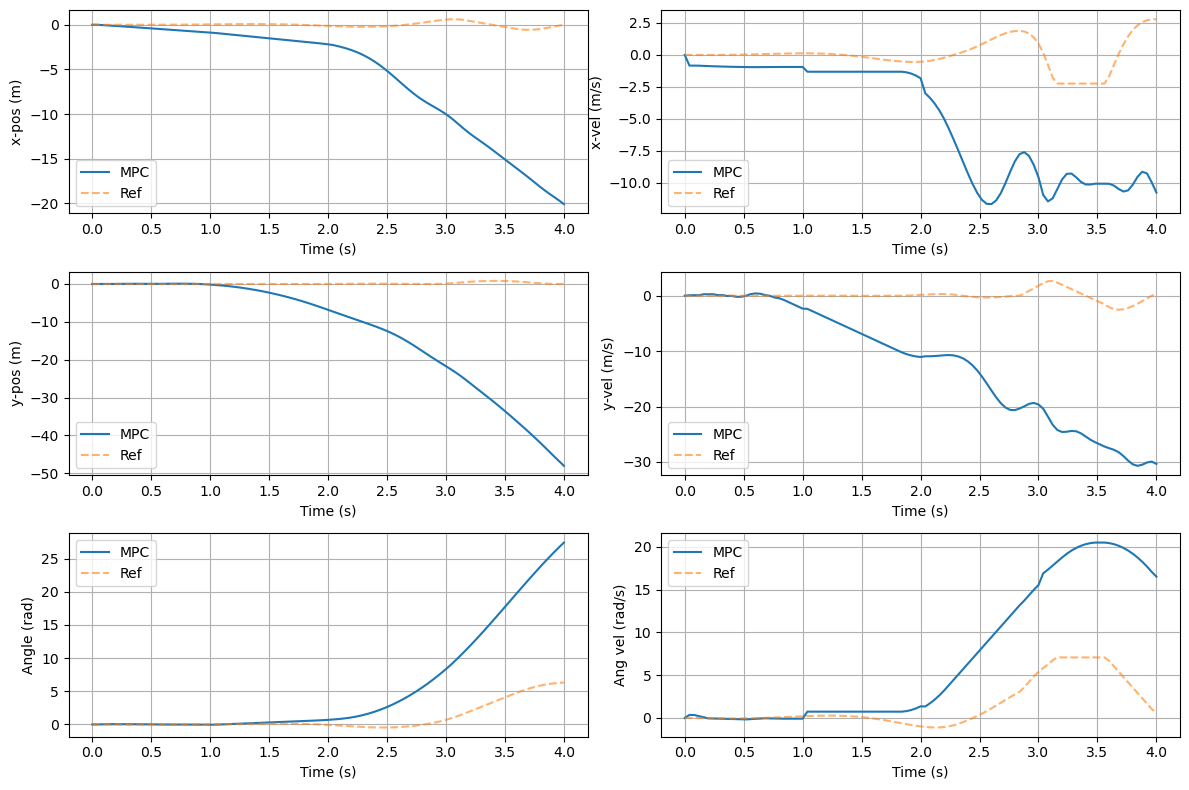

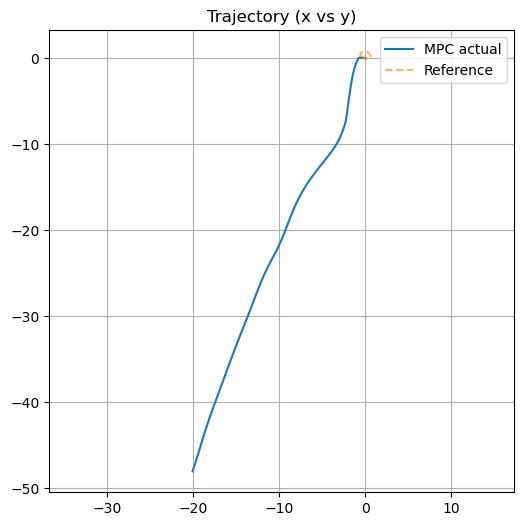

In [118]:
# ---------------------------
# PART 2: SQP/KKT NMPC (single-cell)
# Assumes Part-1 already ran and produced x_sol (xdim x (N+1)) and u_sol (udim x N)
# ---------------------------

import time
import numpy as np
from qpsolvers import solve_qp
import quadrotor
from quadrotor import next_state

# ----- NMPC parameters -----
N_mpc = 30                 # horizon used in NMPC (user requested 60)
sqp_iters_per_step = 3     # small number of SQP iterations each control step
R_stage = 0.1          # stage control weight (user requested small R)
eps_reg = 1e-6             # regularization for QP Hessian
u_min = np.array([0.0, 0.0])
u_max = np.array([10.0, 10.0])
du_max = np.array([1.0, 1.0])   # simple rate limit per timestep (tunable)
print_freq = 1

# state/control dims (consistent with Part-1/quadrotor)
xdim = quadrotor.DIM_STATE
udim = quadrotor.DIM_CONTROL

# make sure references exist
try:
    x_ref_full = x_sol.copy()
    u_ref_full = u_sol.copy()
except NameError:
    raise RuntimeError("Part-1 reference (x_sol, u_sol) not found. Run Part-1 cell first.")

# helper to pack/unpack decision vector Z = [x0,u0, x1,u1, ..., xN]
def pack_Z(x_traj, u_traj):
    # x_traj: (xdim, Nloc+1), u_traj: (udim, Nloc)
    Nloc = u_traj.shape[1]
    nvars = (Nloc * udim) + ((Nloc + 1) * xdim)
    Z = np.zeros(nvars)
    for n in range(Nloc):
        idx_x = n * (xdim + udim)
        idx_u = idx_x + xdim
        Z[idx_x: idx_x + xdim] = x_traj[:, n]
        Z[idx_u: idx_u + udim] = u_traj[:, n]
    idx_xN = Nloc * (xdim + udim)
    Z[idx_xN: idx_xN + xdim] = x_traj[:, Nloc]
    return Z

def unpack_Z(Z, Nloc):
    x = np.zeros((xdim, Nloc + 1))
    u = np.zeros((udim, Nloc))
    for n in range(Nloc):
        idx_x = n * (xdim + udim)
        idx_u = idx_x + xdim
        x[:, n] = Z[idx_x: idx_x + xdim]
        u[:, n] = Z[idx_u: idx_u + udim]
    idx_xN = Nloc * (xdim + udim)
    x[:, Nloc] = Z[idx_xN: idx_xN + xdim]
    return x, u

# cost Hessian construction for local horizon
def build_local_G(Q_stage, R_stage_local, Qf_stage, Nloc):
    nvars = (Nloc * udim) + ((Nloc + 1) * xdim)
    G = np.zeros((nvars, nvars))
    for i in range(Nloc):
        idx_x = i * (xdim + udim)
        G[idx_x: idx_x + xdim, idx_x: idx_x + xdim] = Q_stage
        idx_u = idx_x + xdim
        G[idx_u: idx_u + udim, idx_u: idx_u + udim] = R_stage_local
    idx_xN = Nloc * (xdim + udim)
    G[idx_xN: idx_xN + xdim, idx_xN: idx_xN + xdim] = Qf_stage
    return G

# gradient (linear term) for tracking (q in 0.5 z'Pz + q'z)
def build_local_q(x_traj, u_traj, x_ref_loc, u_ref_loc, Q_stage, R_stage_local, Qf_stage):
    Nloc = u_traj.shape[1]
    nvars = (Nloc * udim) + ((Nloc + 1) * xdim)
    q = np.zeros(nvars)
    for n in range(Nloc):
        idx_x = n * (xdim + udim)
        idx_u = idx_x + xdim
        # note: q is gradient -> for standard quadratic 1/2*z'Pz + q'z where q = linear term
        # Here we use q = -P * z_ref (so that minimizing pulls to z_ref). Simpler: use difference around current Z
        q[idx_x: idx_x + xdim] = - Q_stage @ x_ref_loc[:, n]
        q[idx_u: idx_u + udim] = - R_stage_local @ u_ref_loc[:, n]
    idx_xN = Nloc * (xdim + udim)
    q[idx_xN: idx_xN + xdim] = - Qf_stage @ x_ref_loc[:, Nloc]
    return q

# dynamics linearization A/B (Euler discrete-time linearization as in Part-1)
def calc_A(x_n, u_n):
    # Keep same calc_A as in Part-1 to ensure consistent linearization
    px = x_n[0]; vx = x_n[1]; py = x_n[2]; vy = x_n[3]; theta = x_n[4]; w = x_n[5]
    u1 = u_n[0]; u2 = u_n[1]
    grad_dx = np.zeros((xdim, xdim))
    grad_dx[0,1] = 1.0
    grad_dx[1,4] = -(u1 + u2)*(np.cos(theta))/quadrotor.MASS
    grad_dx[2,3] = 1.0
    grad_dx[3,4] = -(u1 + u2)*(np.sin(theta))/quadrotor.MASS
    grad_dx[4,5] = 1.0
    grad_dx[5,:]  = [0,0,0,0,0,0]
    A_n = np.eye(xdim) + (quadrotor.DT)*(grad_dx)
    return A_n

def calc_B(x_n, u_n):
    theta = x_n[4]
    grad_du = np.zeros((xdim, udim))
    grad_du[0,:] = [0,0]
    grad_du[1,0] = -(np.sin(theta))/quadrotor.MASS
    grad_du[1,1] = -(np.sin(theta))/quadrotor.MASS
    grad_du[2,:] = [0,0]
    grad_du[3,0] = np.cos(theta)/quadrotor.MASS
    grad_du[3,1] = np.cos(theta)/quadrotor.MASS
    grad_du[4,:] = [0,0]
    grad_du[5,0] = quadrotor.LENGTH/quadrotor.INERTIA
    grad_du[5,1] = -(quadrotor.LENGTH)/quadrotor.INERTIA
    B_n = quadrotor.DT * grad_du
    return B_n

# build linear equality constraints M_loc Z = p_loc (dyn linearization)
def build_M_p_from_Z(Z_guess, x0, Nloc):
    n_constr = (Nloc + 1) * xdim
    nvars = Z_guess.size
    M = np.zeros((n_constr, nvars))
    p = np.zeros(n_constr)
    x_mat, u_mat = unpack_Z(Z_guess, Nloc)
    # initial condition
    M[0:xdim, 0:xdim] = np.eye(xdim)
    p[0:xdim] = x0
    # dynamics rows
    for n in range(Nloc):
        x_n = x_mat[:, n].copy()
        u_n = u_mat[:, n].copy()
        x_np1 = x_mat[:, n+1].copy()
        x_np1_pred = next_state(x_n, u_n)
        A_n = calc_A(x_n, u_n)
        B_n = calc_B(x_n, u_n)
        row_s = (n+1)*xdim
        row_e = (n+2)*xdim
        col_xn = n*(xdim + udim)
        col_un = col_xn + xdim
        col_xnp1 = (n+1)*(xdim + udim)
        M[row_s:row_e, col_xn:col_xn+xdim] = A_n
        M[row_s:row_e, col_un:col_un+udim] = B_n
        M[row_s:row_e, col_xnp1:col_xnp1+xdim] = -np.eye(xdim)
        p[row_s:row_e] = x_np1 - x_np1_pred
    return M, p

# inequality constraints H z <= h (control box + ground height constraint)
def build_H_h_from_Z(Z_guess, Nloc, epsilon_ground=1e-3):
    n_ineq = 4 * Nloc + (Nloc + 1)   # 4 control bounds per stage + ground height constraint per state
    H = np.zeros((n_ineq, Z_guess.size))
    h = np.zeros(n_ineq)
    row = 0
    x_mat, u_mat = unpack_Z(Z_guess, Nloc)
    for n in range(Nloc):
        idx_u1 = n*(xdim + udim) + xdim
        idx_u2 = idx_u1 + 1
        # u <= umax
        H[row, idx_u1] = 1.0; h[row] = u_max[0]; row += 1
        H[row, idx_u2] = 1.0; h[row] = u_max[1]; row += 1
        # -u <= -umin  -> u >= umin
        H[row, idx_u1] = -1.0; h[row] = -u_min[0]; row += 1
        H[row, idx_u2] = -1.0; h[row] = -u_min[1]; row += 1
    # ground height constraint: y >= 0 => -y <= -epsilon (we'll use a small epsilon)
    for n in range(Nloc + 1):
        idx_xn_2 = n*(xdim + udim) + 2
        H[row, idx_xn_2] = -1.0
        h[row] = -epsilon_ground
        row += 1
    return H, h

# ----- Global warm-start memory (persist across controller calls) -----
_prev_Zwarm = None
_prev_u_applied = None

# Create a smoother warm-start generator: take slice from reference and pad if needed
def make_initial_Z_warm(x0, t_idx, Nloc):
    # pick reference start index aligned with current time t_idx (t_idx is integer step)
    # prefer to use x_ref_full/u_ref_full if long enough; otherwise use last available and repeat last control
    total_ref_len = x_ref_full.shape[1]
    ref_start = min(t_idx, total_ref_len - 1)
    ref_end = ref_start + Nloc
    if ref_end <= total_ref_len - 1:
        x_ref_loc = x_ref_full[:, ref_start: ref_start + Nloc + 1].copy()
        u_ref_loc = u_ref_full[:, ref_start: ref_start + Nloc].copy()
    else:
        # slice available part, then pad with hover
        avail = max(0, total_ref_len - 1 - ref_start)
        x_ref_loc = np.zeros((xdim, Nloc + 1))
        u_ref_loc = np.zeros((udim, Nloc))
        if avail > 0:
            x_ref_loc[:, :avail+1] = x_ref_full[:, ref_start: ref_start + avail + 1]
            u_ref_loc[:, :avail]  = u_ref_full[:, ref_start: ref_start + avail]
        # pad rest with last reference or hover
        last_x = x_ref_full[:, -1].copy()
        last_u = u_ref_full[:, -1].copy()
        for k in range(avail+1, Nloc+1):
            x_ref_loc[:, k] = last_x
        for k in range(avail, Nloc):
            u_ref_loc[:, k] = last_u
    # pack
    return pack_Z(x_ref_loc, u_ref_loc), x_ref_loc, u_ref_loc

# main NMPC controller factory
def make_sqp_kkt_nmpc():
    global _prev_Zwarm, _prev_u_applied

    def controller(x_current, t_idx):
        # declare globals at very top of controller (fixes earlier global usage bug)
        global _prev_Zwarm, _prev_u_applied

        # SHORT HORIZON ADJUSTMENT: if too close to end of reference, shrink horizon
        remaining_ref = x_ref_full.shape[1] - t_idx
        Nloc = min(N_mpc, max(5, remaining_ref - 1))  # at least 5 steps
        if Nloc <= 0:
            # fallback hover
            u_hover = np.array([quadrotor.MASS*quadrotor.GRAVITY_CONSTANT/2.0,
                                quadrotor.MASS*quadrotor.GRAVITY_CONSTANT/2.0])
            return u_hover

        # build warm-start Z
        if (_prev_Zwarm is None) or (_prev_Zwarm.size != ((Nloc * udim) + ((Nloc + 1) * xdim))):
            Z_warm, x_ref_loc, u_ref_loc = make_initial_Z_warm(x_current, t_idx, Nloc)
        else:
            # shift previous warm by one stage and append last ref
            old_x, old_u = unpack_Z(_prev_Zwarm, prev_Nloc := ( _prev_Zwarm.size - xdim)//(xdim + udim) )
            # if prev_Nloc != Nloc we regenerate
            if prev_Nloc == Nloc:
                x_shift = np.zeros((xdim, Nloc+1))
                u_shift = np.zeros((udim, Nloc))
                # shift: new x0 = current measured state
                x_shift[:, 0] = x_current
                for k in range(0, Nloc):
                    if k < Nloc - 1:
                        x_shift[:, k+1] = old_x[:, k+1]
                    else:
                        # last state: repeat last
                        x_shift[:, k+1] = old_x[:, -1]
                for k in range(0, Nloc):
                    if k < Nloc - 1:
                        u_shift[:, k] = old_u[:, k+1]
                    else:
                        u_shift[:, k] = old_u[:, -1]
                Z_warm = pack_Z(x_shift, u_shift)
            else:
                Z_warm, x_ref_loc, u_ref_loc = make_initial_Z_warm(x_current, t_idx, Nloc)

        # ensure dimensions
        nvars = Z_warm.size

        # cost weights (tracking around reference)
        Q_stage = np.diag([50.0, 2.0, 500.0, 5.0, 800.0, 50.0])   # stronger state tracking
        Qf_stage = np.diag([500.0, 5.0, 2000.0, 10.0, 2500.0, 200.0])
        R_stage_local = np.eye(udim) * R_stage

        # Prepare quadratic cost (Hessian) and linear term q
        # We'll construct q to track the reference embedded in Z_warm (or from reference slices)
        # Extract reference slice for linear term:
        # if we have x_ref_full available for this t_idx, use it, otherwise derive from Z_warm
        total_ref_len = x_ref_full.shape[1]
        if t_idx + Nloc <= total_ref_len - 1:
            x_ref_loc = x_ref_full[:, t_idx: t_idx + Nloc + 1]
            u_ref_loc = u_ref_full[:, t_idx: t_idx + Nloc]
        else:
            # use warm's own states as reference
            x_ref_loc, u_ref_loc = unpack_Z(Z_warm, Nloc)

        G_local = build_local_G(Q_stage, R_stage_local, Qf_stage, Nloc)
        # regularize Hessian
        G_local += eps_reg * np.eye(G_local.shape[0])
        q_local = build_local_q(*unpack_Z(Z_warm, Nloc), x_ref_loc, u_ref_loc, Q_stage, R_stage_local, Qf_stage)

        # SQP inner iterations: linearize dynamics around current Z_guess (start from Z_warm)
        Z_guess = Z_warm.copy()
        for sqp_it in range(sqp_iters_per_step):
            # build linearized equality constraints
            M_loc, p_loc = build_M_p_from_Z(Z_guess, x_current, Nloc)
            # inequalities
            H_loc, h_loc = build_H_h_from_Z(Z_guess, Nloc)
            try:
                # Solve QP: min 0.5 z'G z + q'z s.t. H z <= h, M z = p
                dZ = solve_qp(G_local, q_local, H_loc, h_loc, M_loc, p_loc, solver='cvxopt')
                if dZ is None:
                    # QP failed; break and fallback
                    break
                # interpret solve_qp output as Z solution (not step); we use full step to new Z
                Z_guess = dZ.copy()
            except Exception as e:
                # QP solver error -> break and fallback
                # print("QP fail:", e)
                break

        # store warm for next timestep
        _prev_Zwarm = Z_guess.copy()

        # extract first control from optimized Z_guess
        x_opt, u_opt = unpack_Z(Z_guess, Nloc)
        u_first = u_opt[:, 0].copy()

        # clip to bounds
        u_first = np.clip(u_first, u_min, u_max)

        # apply rate limit relative to last applied
        if _prev_u_applied is None:
            _prev_u_applied = u_first.copy()
        u_first = np.clip(u_first, _prev_u_applied - du_max, _prev_u_applied + du_max)
        _prev_u_applied = u_first.copy()

        # Diagnostics (limited printing)
        if (t_idx % print_freq) == 0:
            # evaluate simple cost/viol for diagnostics
            try:
                x_eval, u_eval = unpack_Z(Z_guess, Nloc)
                cost_eval = 0.0
                viol_eval = 0.0
                for k in range(Nloc):
                    dx = (x_eval[:, k] - x_ref_loc[:, k])
                    cost_eval += 0.5 * (dx @ Q_stage @ dx) + 0.5 * (u_eval[:, k] @ R_stage_local @ u_eval[:, k])
                    # predicted dynamics residual
                    x_pred = next_state(x_eval[:, k], u_eval[:, k])
                    viol_eval += np.sum(np.abs(x_pred - x_eval[:, k+1]))
                # terminal
                dxN = x_eval[:, -1] - x_ref_loc[:, -1]
                cost_eval += 0.5 * (dxN @ Qf_stage @ dxN)
            except Exception:
                cost_eval = np.nan; viol_eval = np.nan

            angle = float(x_current[4])
            ang_vel = float(x_current[5])
            # print compact line
            print(f"[NMPC] t={t_idx:03d}, u_first=[{u_first[0]:.3f}, {u_first[1]:.3f}], angle={angle:+.3f}, ang_vel={ang_vel:+.3f}, cost={cost_eval:.3e}, viol={viol_eval:.3e}")

        return u_first

    return controller

# create controller and simulate
mpc_ctrl = make_sqp_kkt_nmpc()

print("\n" + "="*60)
print("Running SQP/KKT NMPC closed-loop (disturbance=True)...")
print("="*60)
t0 = time.time()
x0 = x_ref_full[:, 0].copy()  # start at Part-1 initial reference
sim_steps = min(250, x_ref_full.shape[1]-1)  # simulate up to ref length or 250 steps

# run simulation (quadrotor.simulate expects (state, controller, horizon_length, disturbance=True))
t_mpc, state_mpc, u_mpc = quadrotor.simulate(x0, mpc_ctrl, sim_steps, True)
print(f"Simulation done in {time.time()-t0:.2f} s")

# compute simple tracking metrics on overlap portion
overlap = min(state_mpc.shape[1], x_ref_full.shape[1])
tracking_norms = np.linalg.norm(state_mpc[:, :overlap] - x_ref_full[:, :overlap], axis=0)
print(f"Final tracking norm (overlap): {np.linalg.norm(tracking_norms):.4f}")
print(f"Tracking norm @ t={4.0:.2f}s : norm = {np.linalg.norm(tracking_norms[int(4.0/quadrotor.DT)]):.4f}" if (int(4.0/quadrotor.DT) < overlap) else "")
print(f"Height min/max: {np.min(state_mpc[2, :]):.3f} {np.max(state_mpc[2, :]):.3f}")

# optionally animate (uncomment if desired)
# quadrotor.animate_robot(state_mpc, u_mpc)

# plotting (compact)
import matplotlib.pyplot as plt
time_states_mpc = np.arange(state_mpc.shape[1]) * quadrotor.DT
time_ref = np.arange(x_ref_full.shape[1]) * quadrotor.DT

plt.figure(figsize=(12,8))
state_labels = ['x-pos (m)', 'x-vel (m/s)', 'y-pos (m)', 'y-vel (m/s)', 'Angle (rad)', 'Ang vel (rad/s)']
for i in range(xdim):
    plt.subplot(3, 2, i+1)
    plt.plot(time_states_mpc, state_mpc[i, :], label='MPC')
    plt.plot(time_ref, x_ref_full[i, :], '--', label='Ref', alpha=0.6)
    plt.ylabel(state_labels[i]); plt.xlabel('Time (s)'); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.plot(state_mpc[0, :], state_mpc[2, :], label='MPC actual')
plt.plot(x_ref_full[0, :], x_ref_full[2, :], '--', label='Reference', alpha=0.6)
plt.title('Trajectory (x vs y)')
plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()


In [130]:
# -----------------------------
# Part-2: NMPC controller cell
# Drop-in replacement for your current controller cell
# -----------------------------

import numpy as np
from qpsolvers import solve_qp
import time

# -----------------------------
# PARAMETERS (adjust if needed)
# -----------------------------
# local MPC horizon (number of stages)
N_mpc = 35                # set smaller for faster loops; you can change to 20/30/60
stage_len = 8             # your Z stage size (6 states + 2 controls)
Zlen = N_mpc * stage_len

# QP inner iterations per control call (SQP inner loops)
max_inner_iters = 5

# actuator bounds
U_MIN = 0.0
U_MAX = 10.0

# -----------------------------
# Build / reuse cost matrix (expects your make_Cost_Matrix function)
# -----------------------------
try:
    Ca_mpc = make_Cost_Matrix(N_mpc)   # keep same weighting architecture as your part-1
except Exception as e:
    print("[NMPC] make_Cost_Matrix failed — make sure it is defined:", e)
    Ca_mpc = np.eye(Zlen) * 1e-3

# -----------------------------
# Global warm-start buffer (persist between controller calls)
# -----------------------------
# we use a module-global variable named Z_warm (safe global, avoids nonlocal)
if 'Z_warm' not in globals() or (isinstance(globals().get('Z_warm'), np.ndarray) and globals().get('Z_warm').size != Zlen):
    # Try to initialize from x_ref_full if available, otherwise from tiled default
    if 'x_ref_full' in globals() and isinstance(x_ref_full, np.ndarray) and x_ref_full.size > 0:
        # if x_ref_full has shape (6, T) and u_ref_full (2, T-1) produce Z sequence of length N_mpc
        try:
            # create initial Z_warm from first N_mpc steps of x_ref_full and u_ref_full
            T_full = x_ref_full.shape[1]
            # If not enough steps, tile last column
            def build_initial_Z_from_ref(start_idx=0):
                Z0 = np.zeros(Zlen)
                for n in range(N_mpc):
                    t_idx = min(start_idx + n, T_full - 1)
                    base = n * stage_len
                    # states
                    Z0[base:base + 6] = x_ref_full[:, t_idx]
                    # controls: use u_ref_full at t_idx if exists else last column or hover
                    if 'u_ref_full' in globals() and isinstance(u_ref_full, np.ndarray) and u_ref_full.shape[1] > 0:
                        ctrl_idx = min(start_idx + n, u_ref_full.shape[1] - 1)
                        Z0[base + 6: base + 8] = u_ref_full[:, ctrl_idx]
                    else:
                        hover = (quadrotor.MASS * quadrotor.GRAVITY_CONSTANT) / 2.0 if hasattr(quadrotor, 'MASS') else 5.0
                        Z0[base + 6: base + 8] = np.array([hover, hover])
                return Z0
            Z_warm = build_initial_Z_from_ref(0)
        except Exception:
            Z_warm = np.zeros(Zlen)
    else:
        # fallback tiled reference (like original)
        hover_guess = (quadrotor.MASS * quadrotor.GRAVITY_CONSTANT) / 2.0 if hasattr(quadrotor, 'MASS') else 5.0
        base_stage = np.array([0.0, 0.0, 2.0, 0.0, 2*np.pi, 0.0, hover_guess, hover_guess])
        Z_warm = np.tile(base_stage, N_mpc)

# -----------------------------
# Helper: slice the right reference window from full reference arrays
# -----------------------------
def build_ref_window(t_idx):
    # Prefer user-provided x_ref_full/u_ref_full
    if 'x_ref_full' in globals() and isinstance(x_ref_full, np.ndarray) and x_ref_full.shape[1] > 0:
        T = x_ref_full.shape[1]
        Xd_win = np.zeros(Zlen)
        for n in range(N_mpc):
            t_ref = min(t_idx + n, T - 1)
            base = n * stage_len
            Xd_win[base: base + 6] = x_ref_full[:, t_ref]
            if 'u_ref_full' in globals() and isinstance(u_ref_full, np.ndarray) and u_ref_full.shape[1] > 0:
                u_t = min(t_idx + n, u_ref_full.shape[1] - 1)
                Xd_win[base + 6: base + 8] = u_ref_full[:, u_t]
            else:
                hover = (quadrotor.MASS * quadrotor.GRAVITY_CONSTANT) / 2.0 if hasattr(quadrotor, 'MASS') else 5.0
                Xd_win[base + 6: base + 8] = np.array([hover, hover])
        return Xd_win
    else:
        hover = (quadrotor.MASS * quadrotor.GRAVITY_CONSTANT) / 2.0 if hasattr(quadrotor, 'MASS') else 5.0
        base_stage = np.array([0.0, 0.0, 2.0, 0.0, 2*np.pi, 0.0, hover, hover])
        return np.tile(base_stage, N_mpc)

# -----------------------------
# Controller function (drop-in for quadrotor.simulate)
# -----------------------------
def nmpc_controller(x, t_idx):
    
    global Z_warm, Ca_mpc

    # ensure shapes
    x = np.asarray(x).flatten()
    if x.size < 6:
        x = np.concatenate([x, np.zeros(6 - x.size)])

    Xd_win = build_ref_window(t_idx)

    Z_warm = np.roll(Z_warm, -stage_len)  # shift left by one stage
    Z_warm[-stage_len:] = Xd_win[-stage_len:]  # last stage <- last ref stage

    # Overwrite first stage's state with current measured state to enforce initial condition
    Z_warm[0:6] = x
    # keep first-stage control from warm-start but clip
    Z_warm[6:8] = np.clip(Z_warm[6:8], U_MIN, U_MAX)

    # filter-line-search bookkeeping
    f_best = float('inf')
    c_best = float('inf')

    # inner SQP iterations (each solves a QP and performs a line-search)
    for it in range(max_inner_iters):
        # build linearized constraints around Z_warm
        try:
            xt, A, b, G, h = get_Constraints(Z_warm)   # must match your implementation
        except Exception as e:
            print(f"[NMPC] get_Constraints failed at t={t_idx}, it={it}: {e}")
            break

        # Quadratic cost: P, linear term q
        P = Ca_mpc
        q = P @ (Z_warm - Xd_win)

        try:
            delta_Z = solve_qp(P=P, q=q, A=A, b=b, G=G, h=h, solver='cvxopt')
        except Exception as e:
            print(f"[NMPC] QP solver exception at t={t_idx}, it={it}: {e}")
            delta_Z = None

        if delta_Z is None:
            # solver failed — leave warm-start as-is and exit inner loop
            print(f"[NMPC] QP returned None at t={t_idx}, it={it}. Using warm-start control.")
            break

        try:
            alpha, uc, gammas = line_search(Z_warm, delta_Z, Xd_win, Ca_mpc, f_best, c_best, alpha=1)
        except TypeError:
            try:
                # try signature with fewer args
                alpha, uc, gammas = line_search(Z_warm, delta_Z, f_best, c_best)
            except TypeError:
                try:
                    alpha, uc, gammas = line_search(Z_warm, delta_Z)
                except Exception as e:
                    print(f"[NMPC] line_search call failed at t={t_idx}, it={it}: {e}")
                    alpha = 0.0
        except Exception as e:
            print(f"[NMPC] line_search threw exception at t={t_idx}, it={it}: {e}")
            alpha = 0.0

        if alpha is None:
            alpha = 0.0

        # Accept step
        Z_warm = Z_warm + alpha * delta_Z

        if alpha < 1e-6 or np.linalg.norm(delta_Z) < 1e-6:
            break

    # extract first control from warm-start (staged layout)
    u0 = Z_warm[6:8].astype(float)
    u0 = np.clip(u0, U_MIN, U_MAX)

    # Debug summary print (safe formatting)
    theta = float(x[4]) if x.size > 4 else 0.0
    w = float(x[5]) if x.size > 5 else 0.0
    print(f"[NMPC] t={t_idx:03d}, u_first=[{u0[0]:.3f}, {u0[1]:.3f}], angle={theta:+.3f}, ang_vel={w:+.3f}")

    return u0


x0 = np.zeros(6)
horizon_length = 250  
t_mpc, state_mpc, u_mpc = quadrotor.simulate(x0, nmpc_controller, horizon_length, disturbance=True)

print("NMPC simulation finished.")
print("Final height:", state_mpc[2, -1])
print("Min height:", np.min(state_mpc[2, :]), "Max height:", np.max(state_mpc[2, :]))

quadrotor.animate_robot(state_mpc, u_mpc)



[NMPC] make_Cost_Matrix failed — make sure it is defined: name 'make_Cost_Matrix' is not defined
[NMPC] get_Constraints failed at t=0, it=0: name 'get_Constraints' is not defined
[NMPC] t=000, u_first=[2.149, 2.267], angle=+0.000, ang_vel=+0.000
[NMPC] get_Constraints failed at t=1, it=0: name 'get_Constraints' is not defined
[NMPC] t=001, u_first=[2.140, 2.277], angle=+0.000, ang_vel=+0.128
[NMPC] get_Constraints failed at t=2, it=0: name 'get_Constraints' is not defined
[NMPC] t=002, u_first=[2.136, 2.280], angle=+0.005, ang_vel=+0.119
[NMPC] get_Constraints failed at t=3, it=0: name 'get_Constraints' is not defined
[NMPC] t=003, u_first=[2.137, 2.279], angle=+0.010, ang_vel=+0.110
[NMPC] get_Constraints failed at t=4, it=0: name 'get_Constraints' is not defined
[NMPC] t=004, u_first=[2.142, 2.273], angle=+0.014, ang_vel=+0.101
[NMPC] get_Constraints failed at t=5, it=0: name 'get_Constraints' is not defined
[NMPC] t=005, u_first=[2.152, 2.262], angle=+0.018, ang_vel=+0.093
[NMPC] ge

Your browser does not support the video tag.